In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print(path)
print(os.listdir(path))

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
/kaggle/input/plantvillage-dataset
['plantvillage dataset']


In [3]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

In [4]:
dataset_path = os.path.join(path, "plantvillage dataset", "color")

print("Classes:", len(os.listdir(dataset_path)))
print(os.listdir(dataset_path)[:10])

Classes: 38
['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot']


In [5]:
IMG_SIZE = 224
BATCH = 32
EPOCHS = 10
SEED = 123

In [6]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Classes:", NUM_CLASSES)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Classes: 38


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [8]:
preprocess_input = tf.keras.applications.mobilenet_v3.preprocess_input

In [9]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

all_labels = np.concatenate([y.numpy() for x, y in train_ds], axis=0)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_labels),
    y=all_labels
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(2.241692466460268), 1: np.float64(2.3003282855024887), 2: np.float64(5.220379716414324), 3: np.float64(0.8814673538124417), 4: np.float64(0.9655938833570412), 5: np.float64(1.3545772012970816), 6: np.float64(1.6170624581255117), 7: np.float64(2.8298593017196456), 8: np.float64(1.1983890543969988), 9: np.float64(1.4563861884009386), 10: np.float64(1.2494679321253954), 11: np.float64(1.2021694615086613), 12: np.float64(1.0308955436381757), 13: np.float64(1.3340293557698213), 14: np.float64(3.4749640057590785), 15: np.float64(0.2616162832711068), 16: np.float64(0.6176462225255196), 17: np.float64(4.112457402499054), 18: np.float64(1.402776880852438), 19: np.float64(0.9535138931565779), 20: np.float64(1.402776880852438), 21: np.float64(1.43086753178315), 22: np.float64(8.931743421052632), 23: np.float64(3.7982164714110858), 24: np.float64(0.28235691723752454), 25: np.float64(0.772475106685633), 26: np.float64(1.2591003941571992), 27: np.float64(3.2387058297301325), 28: np.fl

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)   # ← ВАЖНО
x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.4)(x)

outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 576)            │         2,304 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,098,902 (4.19 MB)

 Trainable params: 158,630 (619.65 KB)

 Non-trainable params: 940,272 (3.59 MB)

In [12]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.3,
        patience=2
    )
]

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 107s 71ms/step - accuracy: 0.5594 - loss: 1.7116 - val_accuracy: 0.9078 - val_loss: 0.2922 - learning_rate: 3.0000e-04
Epoch 2/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 75s 55ms/step - accuracy: 0.8772 - loss: 0.3799 - val_accuracy: 0.9345 - val_loss: 0.2043 - learning_rate: 3.0000e-04
Epoch 3/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 75s 55ms/step - accuracy: 0.9124 - loss: 0.2670 - val_accuracy: 0.9476 - val_loss: 0.1647 - learning_rate: 3.0000e-04
Epoch 4/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 75s 55ms/step - accuracy: 0.9250 - loss: 0.2262 - val_accuracy: 0.9536 - val_loss: 0.1397 - learning_rate: 3.0000e-04
Epoch 5/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 75s 55ms/step - accuracy: 0.9352 - loss: 0.1919 - val_accuracy: 0.9580 - val_loss: 0.1270 - learning_rate: 3.0000e-04
Epoch 6/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 75s 55ms/step - accuracy: 0.9409 - loss: 0.1713 - val_accuracy: 0.9513 - val_loss: 0.1409 - learning_rate: 3.0000e-04
Epoch 7/15
1358/1358 ━━━━━━━━━━━━━━━━━━

In [14]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 92s 61ms/step - accuracy: 0.8879 - loss: 0.3740 - val_accuracy: 0.9553 - val_loss: 0.1363
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 82s 60ms/step - accuracy: 0.9282 - loss: 0.2068 - val_accuracy: 0.9625 - val_loss: 0.1107
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 83s 61ms/step - accuracy: 0.9374 - loss: 0.1782 - val_accuracy: 0.9642 - val_loss: 0.1058
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 82s 60ms/step - accuracy: 0.9466 - loss: 0.1522 - val_accuracy: 0.9663 - val_loss: 0.0963
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 142s 60ms/step - accuracy: 0.9500 - loss: 0.1412 - val_accuracy: 0.9685 - val_loss: 0.0904


In [15]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("jusan.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ TFLite модель сохранена")

Saved artifact at '/tmp/tmpidewvk7e'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_175')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  140154220565840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140156104355536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140156104358416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140154629205712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140156104358032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140154219883664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140154219883856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140154219872912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140154219888080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140154219877712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140154219

In [16]:
from google.colab import files
files.download("jusan.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import numpy as np
from PIL import Image

def predict_image(img_path):
    img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    preds = model.predict(img)[0]
    top3 = preds.argsort()[-3:][::-1]

    for i in top3:
        print(class_names[i], ":", round(preds[i]*100, 2), "%")

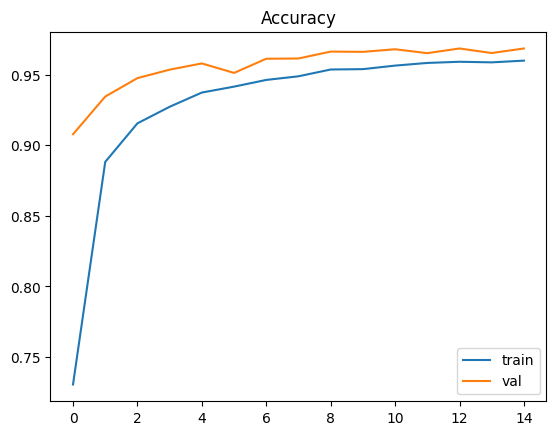

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["train", "val"])
plt.show()

In [24]:
predict_image("grape.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Strawberry___Leaf_scorch : 89.76 %
Grape___Esca_(Black_Measles) : 9.55 %
Pepper,_bell___Bacterial_spot : 0.62 %
